# Training YOLOv9 — Mining Truck Detection

Target akhir: model ONNX untuk Frigate NVR (custom detector, ONNX + CoreML di Mac).

Notebook ini dijalankan per langkah; output tiap sel tersimpan supaya bisa dipantau.

## Langkah 1 — Setup environment

Cek versi Python & paket, dukungan MPS (Apple Silicon GPU), dan uji forward-pass YOLOv9 di MPS.

In [1]:
import sys, platform
import torch, torchvision, ultralytics, roboflow, onnx, onnxruntime

print(f"Python       : {sys.version.split()[0]}  ({platform.machine()}, macOS {platform.mac_ver()[0]})")
print(f"torch        : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"ultralytics  : {ultralytics.__version__}")
print(f"roboflow     : {roboflow.__version__}")
print(f"onnx         : {onnx.__version__}")
print(f"onnxruntime  : {onnxruntime.__version__}")
assert sys.version_info >= (3, 10), "Butuh Python 3.10+"

Python       : 3.14.7  (arm64, macOS 27.0)
torch        : 2.14.0
torchvision  : 0.29.0
ultralytics  : 8.4.155
roboflow     : 1.4.2
onnx         : 1.22.0
onnxruntime  : 1.30.0


In [2]:
print("MPS built     :", torch.backends.mps.is_built())
print("MPS available :", torch.backends.mps.is_available())

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device dipakai:", DEVICE)

# Uji operasi tensor sederhana di device terpilih
x = torch.randn(1024, 1024, device=DEVICE)
y = x @ x.T
print("Matmul OK di", y.device, "| shape", tuple(y.shape))

MPS built     : True
MPS available : True
Device dipakai: mps
Matmul OK di mps:0 | shape (1024, 1024)


In [3]:
import time
from ultralytics import YOLO

# Uji arsitektur YOLOv9 bisa di-load & forward-pass di MPS pada imgsz 320
model = YOLO("weights/yolov9t.pt")
model.info()
dummy = torch.zeros(1, 3, 320, 320, device=DEVICE)
net = model.model.to(DEVICE).eval()
with torch.no_grad():
    for _ in range(3):  # warm-up
        out = net(dummy)
    t0 = time.perf_counter()
    for _ in range(20):
        out = net(dummy)
    if DEVICE == "mps":
        torch.mps.synchronize()
dt = (time.perf_counter() - t0) / 20 * 1000
print(f"Forward pass OK di {DEVICE}: output shape {tuple(out[0].shape)}, ~{dt:.1f} ms/img @320")

YOLOv9t summary: 544 layers, 2,128,720 parameters, 0 gradients, 8.5 GFLOPs


Forward pass OK di mps: output shape (1, 84, 2100), ~45.9 ms/img @320


## Langkah 2 — Download dataset dari Roboflow

Dataset: `ai-rice-quality/mining-truck-v1.4-yypbr` versi 1, format `yolov9`. API key dibaca dari `.env`.

In [4]:
import os
from pathlib import Path
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()
DATASET_DIR = Path("datasets/mining-truck-v1.4").resolve()

if not (DATASET_DIR / "data.yaml").exists():
    rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
    project = rf.workspace("ai-rice-quality").project("mining-truck-v1.4-yypbr")
    dataset = project.version(1).download("yolov9", location=str(DATASET_DIR))
else:
    print("Dataset sudah ada, skip download:", DATASET_DIR)

print(sorted(p.name for p in DATASET_DIR.iterdir()))

Dataset sudah ada, skip download: /Users/andybagus/Training Truck Telkomsat/datasets/mining-truck-v1.4
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'test', 'train', 'valid']


In [5]:
import yaml
from collections import Counter

data_cfg = yaml.safe_load((DATASET_DIR / "data.yaml").read_text())
print("=== data.yaml ===")
print(yaml.safe_dump(data_cfg, sort_keys=False, allow_unicode=True))

names = data_cfg["names"]
names = list(names.values()) if isinstance(names, dict) else list(names)
print(f"Jumlah class (nc): {len(names)}")
for i, n in enumerate(names):
    print(f"  {i}: {n}")

=== data.yaml ===
names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- 777D
- '8'
- '9'
- A
- G
- H
- I
- L
- N
- O
- S
- T
- U
- company
- dumping_soil
- empty_load
- full_load
- mining_truck
- tail_number
nc: 27
roboflow:
  license: CC BY 4.0
  project: mining-truck-v1.4-yypbr
  url: https://universe.roboflow.com/ai-rice-quality/mining-truck-v1.4-yypbr/dataset/1
  version: 1
  workspace: ai-rice-quality
test: ../test/images
train: ../train/images
val: ../valid/images

Jumlah class (nc): 27
  0: 0
  1: 1
  2: 2
  3: 3
  4: 4
  5: 5
  6: 6
  7: 7
  8: 777D
  9: 8
  10: 9
  11: A
  12: G
  13: H
  14: I
  15: L
  16: N
  17: O
  18: S
  19: T
  20: U
  21: company
  22: dumping_soil
  23: empty_load
  24: full_load
  25: mining_truck
  26: tail_number


In [6]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
print(f"{'split':<6} {'images':>7} {'labels':>7} {'kosong':>7} {'boxes':>7}")
split_stats = {}
for split in ["train", "valid", "test"]:
    img_dir, lbl_dir = DATASET_DIR / split / "images", DATASET_DIR / split / "labels"
    if not img_dir.exists():
        print(f"{split:<6} (tidak ada)")
        continue
    imgs = [p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXT]
    lbls = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
    cls_count, empty = Counter(), 0
    for f in lbls:
        rows = [r.split() for r in f.read_text().splitlines() if r.strip()]
        if not rows:
            empty += 1
        cls_count.update(int(r[0]) for r in rows)
    split_stats[split] = cls_count
    print(f"{split:<6} {len(imgs):>7} {len(lbls):>7} {empty:>7} {sum(cls_count.values()):>7}")

print("\nJumlah bounding box per class:")
print(f"{'id':<3} {'class':<25}" + "".join(f"{s:>8}" for s in split_stats))
for i, n in enumerate(names):
    print(f"{i:<3} {n:<25}" + "".join(f"{split_stats[s][i]:>8}" for s in split_stats))

split   images  labels  kosong   boxes
train      301     301       0    6377
valid       86      86       0    1586
test        43      43       0     949

Jumlah bounding box per class:
id  class                       train   valid    test
0   0                             260      32      18
1   1                              48      90      39
2   2                              48      18      12
3   3                              50       1       0
4   4                              19      16       9
5   5                              26       1       0
6   6                              44       2       0
7   7                               3       7       6
8   777D                          294      82      42
9   8                              65       4       0
10  9                              46       1       2
11  A                             971     219     145
12  G                             277      63      40
13  H                             510     118      78
14

In [7]:
# Cek cepat ukuran gambar & format label (harus: class cx cy w h, ternormalisasi 0-1)
from PIL import Image
sample_imgs = sorted((DATASET_DIR / "train" / "images").iterdir())[:200]
sizes = Counter(Image.open(p).size for p in sample_imgs)
print("Ukuran gambar (sample 200 train):", sizes.most_common(5))

bad = 0
for f in (DATASET_DIR / "train" / "labels").glob("*.txt"):
    for r in f.read_text().splitlines():
        v = r.split()
        if v and (len(v) != 5 or not all(0 <= float(x) <= 1 for x in v[1:])):
            bad += 1
print("Baris label train yang bukan format bbox 5 kolom / di luar 0-1:", bad)

Ukuran gambar (sample 200 train): [((907, 711), 2), ((902, 708), 2), ((918, 685), 2), ((918, 716), 2), ((840, 687), 1)]
Baris label train yang bukan format bbox 5 kolom / di luar 0-1: 5773


## Langkah 2b — Filter class, konversi label, split ulang

Keputusan setelah analisis dataset:
- **3 class**: `truck` (gabungan `mining_truck` + `dumping_soil`), `full_load`, `empty_load`. 20 class karakter (3–15 px @320), `777D`, `company`, `tail_number` dibuang.
- Label asli campur polygon 4-titik & bbox dalam satu file → dikonversi semua ke bbox `cls cx cy w h`.
- Split ulang **70/20/10** stratified per (sumber label truk, status muatan), seed 42.

Dataset asli di `datasets/mining-truck-v1.4` tidak diubah; hasil di `datasets/mining-truck-clean`.

In [8]:
import random, shutil
from collections import defaultdict

SRC_DIR = DATASET_DIR
CLEAN_DIR = Path("datasets/mining-truck-clean").resolve()
NEW_NAMES = ["truck", "full_load", "empty_load"]
CLASS_MAP = {"mining_truck": 0, "dumping_soil": 0, "full_load": 1, "empty_load": 2}
old_id_to_new = {i: CLASS_MAP[n] for i, n in enumerate(names) if n in CLASS_MAP}
SPLIT_RATIO = {"train": 0.7, "valid": 0.2, "test": 0.1}
SEED = 42

def to_bbox(vals):
    """Polygon (x1 y1 x2 y2 ...) atau bbox (cx cy w h) -> bbox (cx cy w h), di-clip ke 0-1."""
    if len(vals) == 4:
        cx, cy, w, h = vals
        x1, y1, x2, y2 = cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2
    else:
        xs, ys = vals[0::2], vals[1::2]
        x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
    x1, y1, x2, y2 = (min(max(v, 0.0), 1.0) for v in (x1, y1, x2, y2))
    return (x1 + x2) / 2, (y1 + y2) / 2, x2 - x1, y2 - y1

# Kumpulkan semua sampel dari 3 split asli + tentukan strata
samples = []
for split in ["train", "valid", "test"]:
    for lbl in sorted((SRC_DIR / split / "labels").glob("*.txt")):
        img = next((SRC_DIR / split / "images").glob(lbl.stem + ".*"))
        boxes, src_classes = [], set()
        for row in lbl.read_text().splitlines():
            v = row.split()
            if not v or int(v[0]) not in old_id_to_new:
                continue
            src_classes.add(names[int(v[0])])
            cx, cy, w, h = to_bbox(list(map(float, v[1:])))
            if w > 0 and h > 0:
                boxes.append(f"{old_id_to_new[int(v[0])]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        truck_src = "mining_truck" if "mining_truck" in src_classes else "dumping_soil"
        load = "+".join(sorted(src_classes & {"full_load", "empty_load"})) or "none"
        samples.append({"img": img, "boxes": boxes, "stratum": (truck_src, load)})

# Split stratified
rng = random.Random(SEED)
by_stratum = defaultdict(list)
for s in samples:
    by_stratum[s["stratum"]].append(s)
assignment = {"train": [], "valid": [], "test": []}
for stratum, items in sorted(by_stratum.items()):
    rng.shuffle(items)
    n = len(items)
    n_test = round(n * SPLIT_RATIO["test"])
    n_valid = round(n * SPLIT_RATIO["valid"])
    assignment["test"] += items[:n_test]
    assignment["valid"] += items[n_test:n_test + n_valid]
    assignment["train"] += items[n_test + n_valid:]

# Tulis dataset bersih — hanya kalau belum ada atau REBUILD=True (jangan rebuild saat training berjalan)
REBUILD = False
if REBUILD or not (CLEAN_DIR / "data.yaml").exists():
    if CLEAN_DIR.exists():
        shutil.rmtree(CLEAN_DIR)
    for split, items in assignment.items():
        (CLEAN_DIR / split / "images").mkdir(parents=True)
        (CLEAN_DIR / split / "labels").mkdir(parents=True)
        for s in items:
            shutil.copy2(s["img"], CLEAN_DIR / split / "images" / s["img"].name)
            (CLEAN_DIR / split / "labels" / (s["img"].stem + ".txt")).write_text("\n".join(s["boxes"]) + "\n")
    (CLEAN_DIR / "data.yaml").write_text(yaml.safe_dump({
        "path": str(CLEAN_DIR),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": len(NEW_NAMES),
        "names": NEW_NAMES,
    }, sort_keys=False))
else:
    print("Dataset bersih sudah ada, skip rebuild:", CLEAN_DIR)
print((CLEAN_DIR / "data.yaml").read_text())
print("Strata (sumber truk, muatan) -> jumlah gambar:")
for k, v in sorted(by_stratum.items(), key=lambda kv: -len(kv[1])):
    print(f"  {k}: {len(v)}")

Dataset bersih sudah ada, skip rebuild: /Users/andybagus/Training Truck Telkomsat/datasets/mining-truck-clean
path: /Users/andybagus/Training Truck Telkomsat/datasets/mining-truck-clean
train: train/images
val: valid/images
test: test/images
nc: 3
names:
- truck
- full_load
- empty_load

Strata (sumber truk, muatan) -> jumlah gambar:
  ('dumping_soil', 'full_load'): 259
  ('mining_truck', 'full_load'): 108
  ('mining_truck', 'empty_load'): 61
  ('dumping_soil', 'none'): 1
  ('mining_truck', 'empty_load+full_load'): 1


In [9]:
print(f"{'split':<6} {'images':>7}" + "".join(f"{n:>12}" for n in NEW_NAMES))
for split in ["train", "valid", "test"]:
    cnt = Counter()
    files = list((CLEAN_DIR / split / "labels").glob("*.txt"))
    for f in files:
        cnt.update(int(r.split()[0]) for r in f.read_text().splitlines() if r.strip())
    n_img = len(list((CLEAN_DIR / split / "images").iterdir()))
    assert n_img == len(files)
    print(f"{split:<6} {n_img:>7}" + "".join(f"{cnt[i]:>12}" for i in range(len(NEW_NAMES))))

split   images       truck   full_load  empty_load


train      301         305         257          46
valid       86          88          75          12
test        43          43          37           6


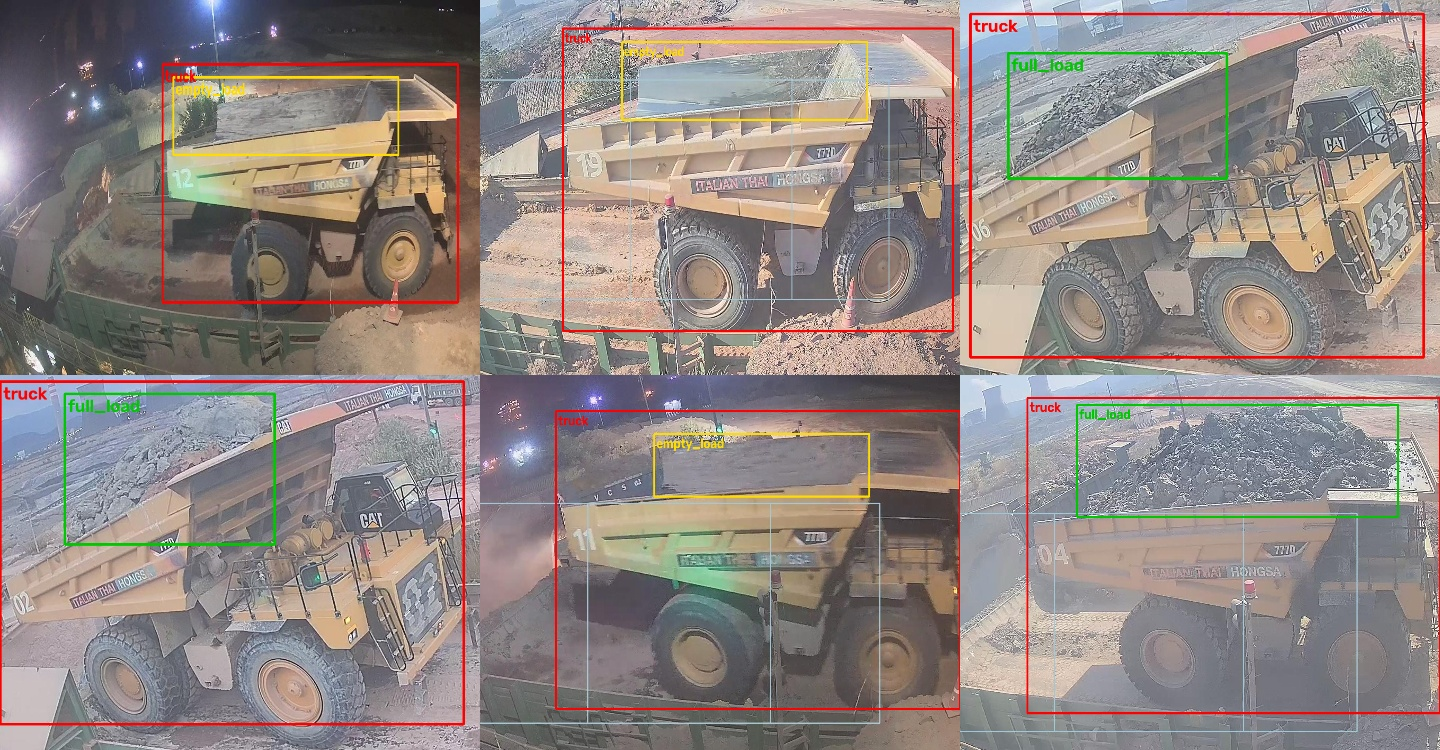

In [10]:
# Visual check: gambar label hasil konversi pada beberapa sampel acak
import cv2, numpy as np
from IPython.display import Image as IPImage, display

COLORS = [(0, 0, 255), (0, 200, 0), (0, 220, 255)]
picks = random.Random(0).sample(sorted((CLEAN_DIR / "train" / "labels").glob("*.txt")), 6)
tiles = []
for f in picks:
    im = cv2.imread(str(next((CLEAN_DIR / "train" / "images").glob(f.stem + ".*"))))
    H, W = im.shape[:2]
    for row in f.read_text().splitlines():
        c, cx, cy, w, h = row.split(); c = int(c); cx, cy, w, h = map(float, (cx, cy, w, h))
        p1 = (int((cx - w / 2) * W), int((cy - h / 2) * H)); p2 = (int((cx + w / 2) * W), int((cy + h / 2) * H))
        cv2.rectangle(im, p1, p2, COLORS[c], 4)
        cv2.putText(im, NEW_NAMES[c], (p1[0] + 6, p1[1] + 34), cv2.FONT_HERSHEY_SIMPLEX, 1.1, COLORS[c], 3)
    tiles.append(cv2.resize(im, (480, 375)))
grid = np.vstack([np.hstack(tiles[:3]), np.hstack(tiles[3:])])
Path("runs").mkdir(exist_ok=True)
cv2.imwrite("runs/clean_label_check.jpg", grid)
display(IPImage("runs/clean_label_check.jpg"))

## Langkah 3 — Konfigurasi training

Konfigurasi ada di `train.py` (satu sumber, dipakai notebook & CLI).

| Parameter | Nilai | Alasan |
|---|---|---|
| Base model | `yolov9t` (2,1 jt param) | 301 gambar train, 3 class, objek besar (truk ~250 px @320). Model kecil cukup & risiko overfit rendah; paling ringan untuk real-time di Frigate. `yolov9c` (25 jt param) terlalu besar untuk data sekecil ini. |
| imgsz | 320 | Sesuai input Frigate; objek (truk & bak muatan) tetap ≥50 px. |
| epochs / patience | 150 / 40 | Batch 16 → hanya ~19 iterasi/epoch, jadi butuh banyak epoch; early stopping menghentikan kalau val mAP stagnan. |
| batch | 16 | Banyak update gradien per epoch pada data kecil; BatchNorm masih stabil; memori MPS @320 aman. |
| optimizer / lr0 | AdamW / 0.001, cosine → 1e-5, warmup 3 | Fine-tune dari bobot COCO: LR rendah supaya fitur pretrained tidak rusak; AdamW konvergen cepat di dataset kecil. |
| Augmentasi | mosaic (off 15 epoch terakhir), mixup 0.1, rotasi ±5°, flip horizontal, hsv_v 0.5 | Menambah variasi data kecil; brightness lebih besar karena ada gambar malam. Tanpa flip vertikal (truk tidak pernah terbalik). |
| device | `mps`, fallback `cpu` | Apple Silicon GPU. |

In [11]:
import importlib, train as train_mod
importlib.reload(train_mod)
print("Device  :", train_mod.DEVICE)
print("Weights :", train_mod.BASE_WEIGHTS, train_mod.BASE_WEIGHTS.exists())
print("Data    :", train_mod.DATA_YAML, train_mod.DATA_YAML.exists())
for k, v in train_mod.TRAIN_CFG.items():
    print(f"  {k:<14} {v}")

Device  : mps
Weights : /Users/andybagus/Training Truck Telkomsat/weights/yolov9t.pt True
Data    : /Users/andybagus/Training Truck Telkomsat/datasets/mining-truck-clean/data.yaml True
  data           /Users/andybagus/Training Truck Telkomsat/datasets/mining-truck-clean/data.yaml
  imgsz          320
  epochs         150
  patience       40
  batch          16
  optimizer      AdamW
  lr0            0.001
  lrf            0.01
  cos_lr         True
  warmup_epochs  3
  weight_decay   0.0005
  mosaic         1.0
  close_mosaic   15
  mixup          0.1
  degrees        5.0
  fliplr         0.5
  flipud         0.0
  hsv_v          0.5
  cache          ram
  workers        4
  device         mps
  seed           42
  deterministic  False
  project        /Users/andybagus/Training Truck Telkomsat/runs
  name           yolov9t_truck_320
  exist_ok       False
  plots          True


## Langkah 4 — Training

Training dijalankan dari terminal (bukan dari notebook) supaya tidak terikat kernel:

```bash
.venv/bin/python train.py --epochs 3 --name smoke_test   # percobaan 3 epoch
.venv/bin/python train.py > logs/train_full.log 2>&1     # training penuh
```

Sel di bawah membaca `results.csv` untuk memantau loss & mAP.

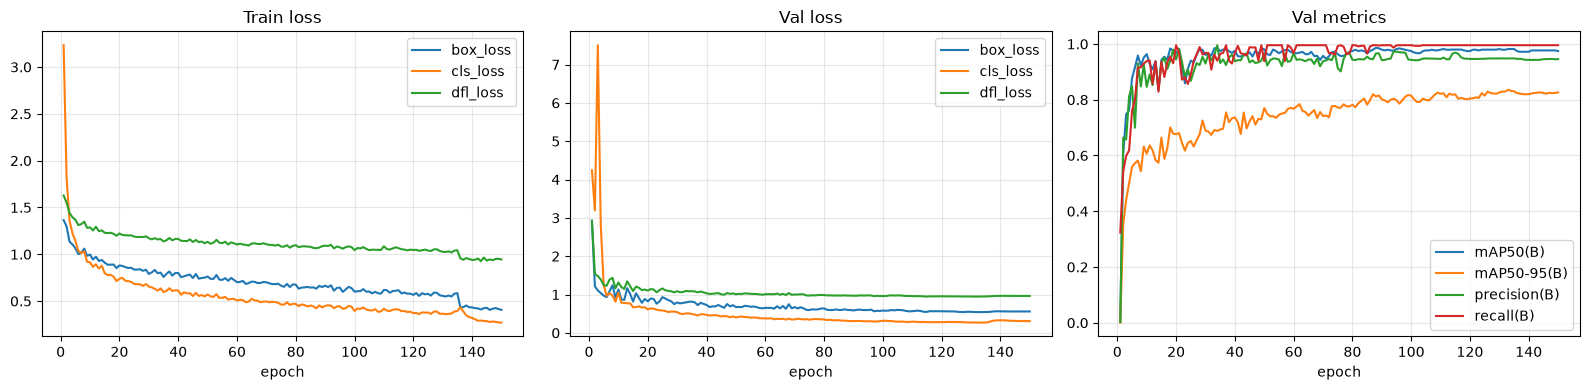

Epoch dijalankan : 150  (durasi 27.8 menit)
Epoch terbaik    : 133
  mAP50          : 0.982
  mAP50-95       : 0.836
  precision      : 0.948
  recall         : 0.996


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path("runs/yolov9t_truck_320").resolve()
res = pd.read_csv(RUN_DIR / "results.csv")
res.columns = res.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for col in ["train/box_loss", "train/cls_loss", "train/dfl_loss"]:
    axes[0].plot(res["epoch"], res[col], label=col.split("/")[1])
for col in ["val/box_loss", "val/cls_loss", "val/dfl_loss"]:
    axes[1].plot(res["epoch"], res[col], label=col.split("/")[1])
for col in ["metrics/mAP50(B)", "metrics/mAP50-95(B)", "metrics/precision(B)", "metrics/recall(B)"]:
    axes[2].plot(res["epoch"], res[col], label=col.split("/")[1])
for ax, t in zip(axes, ["Train loss", "Val loss", "Val metrics"]):
    ax.set_title(t); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

best = res.loc[res["metrics/mAP50-95(B)"].idxmax()]
print(f"Epoch dijalankan : {int(res['epoch'].max())}  (durasi {res['time'].iloc[-1] / 60:.1f} menit)")
print(f"Epoch terbaik    : {int(best['epoch'])}")
print(f"  mAP50          : {best['metrics/mAP50(B)']:.3f}")
print(f"  mAP50-95       : {best['metrics/mAP50-95(B)']:.3f}")
print(f"  precision      : {best['metrics/precision(B)']:.3f}")
print(f"  recall         : {best['metrics/recall(B)']:.3f}")

## Langkah 5a — Validasi `best.pt` pada split valid & test

In [13]:
best_model = YOLO(str(RUN_DIR / "weights" / "best.pt"))
DATA_CLEAN = str(CLEAN_DIR / "data.yaml")

rows = []
for split in ["val", "test"]:
    m = best_model.val(data=DATA_CLEAN, split=split, imgsz=320, batch=16, device=DEVICE,
                       project=str(RUN_DIR), name=f"eval_{split}", exist_ok=True, verbose=False)
    rows.append({"split": split, "class": "all", "P": m.box.mp, "R": m.box.mr,
                 "mAP50": m.box.map50, "mAP50-95": m.box.map})
    for i, c in enumerate(m.box.ap_class_index):
        p, r, ap50, ap = m.box.class_result(i)
        rows.append({"split": split, "class": m.names[c], "P": p, "R": r, "mAP50": ap50, "mAP50-95": ap})
metrics_df = pd.DataFrame(rows).set_index(["split", "class"]).round(3)
metrics_df

Ultralytics 8.4.155 🚀 Python-3.14.7 torch-2.14.0 MPS (Apple M1 Pro)


YOLOv9t summary (fused): 197 layers, 1,971,369 parameters, 0 gradients, 7.6 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2820.5±720.3 MB/s, size: 140.0 KB)


val: Scanning /Users/andybagus/Training Truck Telkomsat/datasets/mining-truck-clean/valid/labels.cache... 86 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 86/86 27.7Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 16% ━━────────── 1/6 1.7s/it 0.5s<8.4s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.2it/s 1.0s

                   all         43         86      0.994      0.997      0.995      0.854


Speed: 0.1ms preprocess, 7.3ms inference, 0.0ms loss, 1.5ms postprocess per image


Results saved to /Users/andybagus/Training Truck Telkomsat/runs/yolov9t_truck_320/eval_test


P      R  mAP50  mAP50-95
split class                                    
val   all         0.947  0.996  0.982     0.831
      truck       0.996  1.000  0.995     0.948
      full_load   0.993  0.987  0.995     0.808
      empty_load  0.852  1.000  0.956     0.737
test  all         0.994  0.997  0.995     0.854
      truck       0.997  1.000  0.995     0.939
      full_load   1.000  0.990  0.995     0.834
      empty_load  0.984  1.000  0.995     0.787

## Langkah 5b — Export ONNX untuk Frigate

- Input `images`: `[1, 3, 320, 320]` float32, RGB, dinormalisasi 0–1 (NCHW)
- Output `[1, 7, 2100]` = 4 koordinat box (cx, cy, w, h dalam piksel) + 3 skor class, **tanpa NMS** (NMS dilakukan Frigate)
- opset 17, di-simplify, shape statis — kompatibel dengan onnxruntime di Frigate & CoreML EP

In [14]:
EXPORT_DIR = Path("export/frigate_onnx").resolve()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
ONNX_NAME = "mining_truck_yolov9t_320.onnx"

onnx_tmp = best_model.export(format="onnx", imgsz=320, opset=17, simplify=True,
                             dynamic=False, nms=False, batch=1)
ONNX_PATH = EXPORT_DIR / ONNX_NAME
shutil.copy2(onnx_tmp, ONNX_PATH)
(EXPORT_DIR / "labelmap.txt").write_text("".join(f"{i} {n}\n" for i, n in enumerate(NEW_NAMES)))
print("ONNX     :", ONNX_PATH, f"({ONNX_PATH.stat().st_size / 1e6:.1f} MB)")
print("labelmap :", (EXPORT_DIR / "labelmap.txt").read_text())

Ultralytics 8.4.155 🚀 Python-3.14.7 torch-2.14.0 CPU (Apple M1 Pro)


WARNING ⚠️ This model has no one-to-one head; using one-to-many outputs.


YOLOv9t summary (fused): 197 layers, 1,971,369 parameters, 0 gradients, 1.9 GFLOPs



PyTorch: starting from '/Users/andybagus/Training Truck Telkomsat/runs/yolov9t_truck_320/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (4.4 MB)



ONNX: starting export with onnx 1.22.0 opset 17...


ONNX: slimming with onnxslim 0.1.96...


ONNX: export success ✅ 1.2s, saved as '/Users/andybagus/Training Truck Telkomsat/runs/yolov9t_truck_320/weights/best.onnx' (7.8 MB)



Export complete (1.3s)
Results saved to /Users/andybagus/Training Truck Telkomsat/runs/yolov9t_truck_320/weights/best.onnx
Predict:         yolo predict task=detect model=/Users/andybagus/Training Truck Telkomsat/runs/yolov9t_truck_320/weights/best.onnx imgsz=320 
Validate:        yolo val task=detect model=/Users/andybagus/Training Truck Telkomsat/runs/yolov9t_truck_320/weights/best.onnx imgsz=320 data=/Users/andybagus/Training Truck Telkomsat/datasets/mining-truck-clean/data.yaml  
Visualize:       https://netron.app


ONNX     : /Users/andybagus/Training Truck Telkomsat/export/frigate_onnx/mining_truck_yolov9t_320.onnx (8.2 MB)
labelmap : 0 truck
1 full_load
2 empty_load



In [15]:
# Verifikasi ONNX: struktur, CPU vs PyTorch, dan CoreML EP vs CPU setelah NMS (CoreML jalan FP16 → output mentah sedikit beda)
import onnxruntime as ort, torchvision

onnx.checker.check_model(onnx.load(str(ONNX_PATH)))
print("onnx.checker OK | providers tersedia:", ort.get_available_providers())

def prep(p):
    im = cv2.cvtColor(cv2.resize(cv2.imread(str(p)), (320, 320)), cv2.COLOR_BGR2RGB)
    return np.ascontiguousarray(im.transpose(2, 0, 1)[None], dtype=np.float32) / 255.0

def decode(out, conf=0.4, iou=0.5):
    """[1, 4+nc, N] -> (boxes xyxy, class, score) setelah NMS per class."""
    o = out[0].T
    scores, cls = o[:, 4:].max(1), o[:, 4:].argmax(1)
    k = scores > conf
    b = torch.tensor(o[k, :4])
    b = torch.cat([b[:, :2] - b[:, 2:] / 2, b[:, :2] + b[:, 2:] / 2], 1)
    keep = torchvision.ops.batched_nms(b, torch.tensor(scores[k]), torch.tensor(cls[k]), iou).numpy()
    return b.numpy()[keep], cls[k][keep], scores[k][keep]

sess_cpu = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
sess_cml = ort.InferenceSession(str(ONNX_PATH), providers=["CoreMLExecutionProvider", "CPUExecutionProvider"])
inp = sess_cpu.get_inputs()[0]
print(f"input {inp.name}{inp.shape} {inp.type} | output {sess_cpu.get_outputs()[0].name}{sess_cpu.get_outputs()[0].shape}")

# 1) ONNX (CPU) vs PyTorch
torch_net = YOLO(str(RUN_DIR / "weights" / "best.pt")).model.float().cpu().eval()
x = prep(sorted((CLEAN_DIR / "test" / "images").iterdir())[0])
with torch.no_grad():
    torch_out = torch_net(torch.from_numpy(x))[0].numpy()
print(f"ONNX CPU vs PyTorch: max|diff| {np.abs(sess_cpu.run(None, {inp.name: x})[0] - torch_out).max():.5f}")

# 2) CoreML EP vs CPU EP pada deteksi akhir (semua gambar test)
n_box, n_mismatch, min_iou, max_score_gap = 0, 0, 1.0, 0.0
for p in sorted((CLEAN_DIR / "test" / "images").iterdir()):
    x = prep(p)
    da, db = decode(sess_cpu.run(None, {inp.name: x})[0]), decode(sess_cml.run(None, {inp.name: x})[0])
    n_box += len(da[0])
    if sorted(da[1]) != sorted(db[1]):
        n_mismatch += 1
        continue
    for i in range(len(da[0])):
        j = [k for k in range(len(db[0])) if db[1][k] == da[1][i]]
        ious = torchvision.ops.box_iou(torch.tensor(da[0][i:i + 1]), torch.tensor(db[0][j])).numpy()[0]
        min_iou = min(min_iou, ious.max())
        max_score_gap = max(max_score_gap, abs(da[2][i] - db[2][j[ious.argmax()]]))
print(f"CoreML vs CPU (conf>0.4 + NMS, {n_box} box test): gambar beda {n_mismatch} | IoU min {min_iou:.3f} | selisih skor max {max_score_gap:.4f}")

# 3) Kecepatan
for name, sess in [("CPU", sess_cpu), ("CoreML", sess_cml)]:
    for _ in range(5):
        sess.run(None, {inp.name: x})
    t0 = time.perf_counter()
    for _ in range(100):
        sess.run(None, {inp.name: x})
    print(f"{name:<7}: {(time.perf_counter() - t0) / 100 * 1000:.1f} ms/img")

onnx.checker OK | providers tersedia: ['CoreMLExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
input images[1, 3, 320, 320] tensor(float) | output output0[1, 7, 2100]


ONNX CPU vs PyTorch: max|diff| 0.00023


CoreML vs CPU (conf>0.4 + NMS, 87 box test): gambar beda 0 | IoU min 0.975 | selisih skor max 0.0051


CPU    : 13.8 ms/img


CoreML : 2.3 ms/img


In [16]:
# mAP dari file ONNX (bukan .pt) di split test — memastikan export tidak menurunkan akurasi
onnx_model = YOLO(str(ONNX_PATH), task="detect")
m = onnx_model.val(data=DATA_CLEAN, split="test", imgsz=320, batch=1, device="cpu",
                   project=str(RUN_DIR), name="eval_test_onnx", exist_ok=True, verbose=False)
print(f"ONNX test  : mAP50 {m.box.map50:.3f} | mAP50-95 {m.box.map:.3f} | P {m.box.mp:.3f} | R {m.box.mr:.3f}")
print(f"PyTorch test: mAP50 {metrics_df.loc[('test', 'all'), 'mAP50']:.3f} | mAP50-95 {metrics_df.loc[('test', 'all'), 'mAP50-95']:.3f}")

Ultralytics 8.4.155 🚀 Python-3.14.7 torch-2.14.0 CPU (Apple M1 Pro)


Loading /Users/andybagus/Training Truck Telkomsat/export/frigate_onnx/mining_truck_yolov9t_320.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.30.0 with CPUExecutionProvider


Setting batch=1 input of shape (1, 3, 320, 320)


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3115.3±553.3 MB/s, size: 150.8 KB)


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 51.8it/s 0.8s

                   all         43         86      0.995      0.992      0.995      0.847


Speed: 0.2ms preprocess, 14.6ms inference, 0.0ms loss, 0.3ms postprocess per image


Results saved to /Users/andybagus/Training Truck Telkomsat/runs/yolov9t_truck_320/eval_test_onnx


ONNX test  : mAP50 0.995 | mAP50-95 0.847 | P 0.995 | R 0.992
PyTorch test: mAP50 0.995 | mAP50-95 0.854
